In [179]:
import pandas as pd
import matplotlib.pyplot as plt

In [180]:
# We can see from the first research question that the biggest polluters are:
#1. China
#2. US
#3. Russia
#4. Japan
#5. Germany
#6. India
#7. UK
#8. Saudi Arabia
#9. Iran
#10. France

goliaths_iso3 = ["CHN", "USA", "RUS", "JPN", "DEU", "IND", "GBR", "SAU", "IRN", "FRA"]

In [181]:
# Load and filter data
df = pd.read_csv("data/owid-co2-data.csv")

START_YEAR = 1990
END_YEAR = int(df["year"].max())
df = df[(df["year"] >= START_YEAR) & (df["year"] <= END_YEAR)].copy()

df_goliaths = df[df["iso_code"].isin(goliaths_iso3)].copy()

df_goliaths = df_goliaths[df_goliaths["co2"].notna()].copy()

df_goliaths.head()

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
9899,China,1990,CHN,1.153583e+09,3.385122e+12,83.068,0.072,2483.534,21.384,0.869,...,19.043,7.329,0.024,0.044,0.072,0.003,4205.167,3050.701,-122.764,-4.943
9900,China,1991,CHN,1.170789e+09,3.508948e+12,99.573,0.085,2619.143,135.609,5.460,...,23.957,7.421,0.025,0.046,0.074,0.004,4315.059,3185.453,-161.227,-6.156
9901,China,1992,CHN,1.184574e+09,3.755038e+12,120.352,0.102,2731.290,112.147,4.282,...,23.790,7.516,0.026,0.047,0.076,0.004,4445.956,3302.529,-73.106,-2.677
9902,China,1993,CHN,1.197309e+09,4.126169e+12,140.333,0.117,2914.284,182.994,6.700,...,25.492,7.617,0.026,0.049,0.079,0.004,4591.354,3497.279,-104.192,-3.575
9903,China,1994,CHN,1.209003e+09,4.438753e+12,161.567,0.134,3093.891,179.606,6.163,...,25.425,7.725,0.027,0.050,0.081,0.004,4901.601,3692.746,-301.852,-9.756


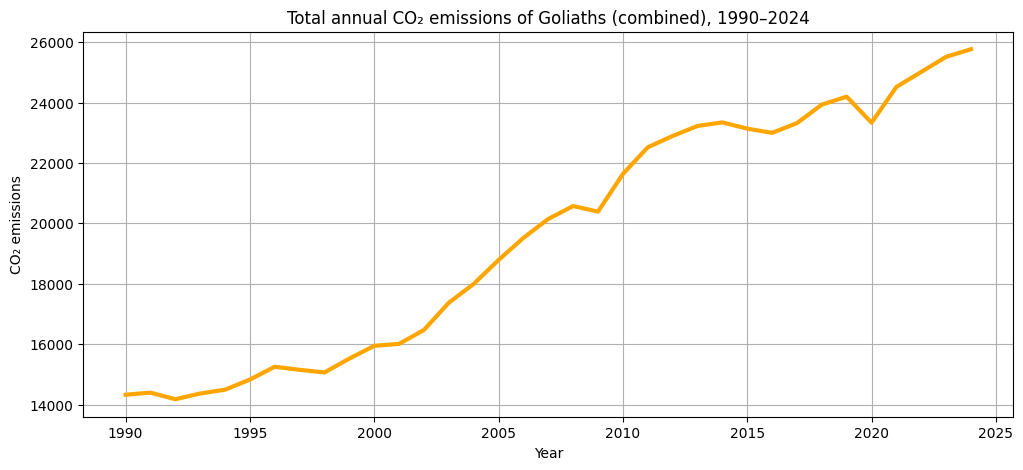

In [182]:
# Total annual CO2 emissions of all Goliaths combined
goliaths_total_yearly = (
    df_goliaths.groupby("year", as_index=False)["co2"]
    .sum()
    .rename(columns={"co2": "goliaths_total_co2"})
)

plt.figure(figsize=(12, 5))
plt.plot(
    goliaths_total_yearly["year"],
    goliaths_total_yearly["goliaths_total_co2"],
    linewidth=3,
    color='orange'
)
plt.title(f"Total annual CO₂ emissions of Goliaths (combined), {START_YEAR}–{END_YEAR}")
plt.xlabel("Year")
plt.ylabel("CO₂ emissions")
plt.grid(True)
plt.show()

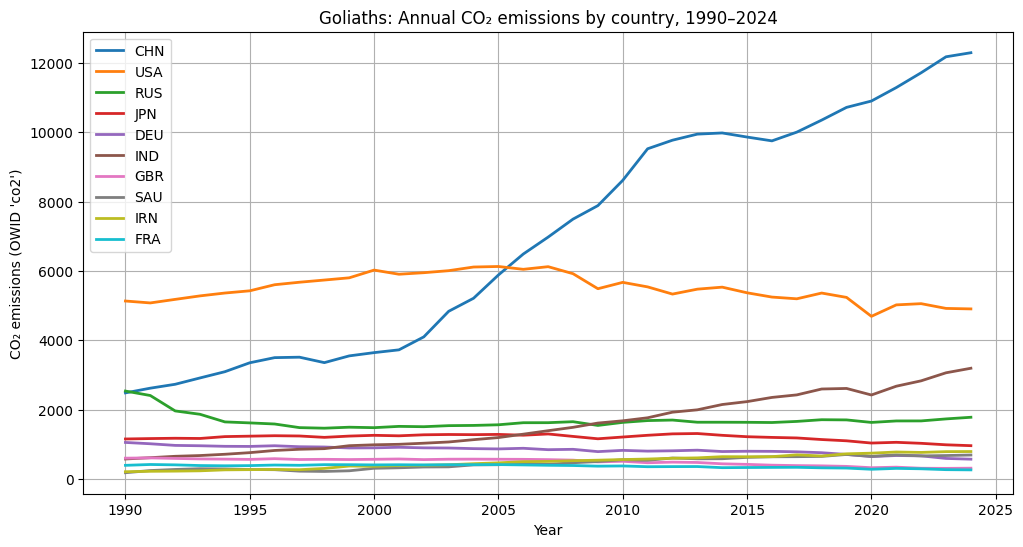

In [183]:
# Annual CO2 emissions per Goliath
goliaths_by_country_yearly = df_goliaths.pivot_table(
    index="year",
    columns="iso_code",
    values="co2",
    aggfunc="sum"
).reset_index()

plt.figure(figsize=(12, 6))

for code in goliaths_iso3:
    if code in goliaths_by_country_yearly.columns:
        plt.plot(
            goliaths_by_country_yearly["year"], 
            goliaths_by_country_yearly[code], 
            label=code,
            linewidth=2,
        )

plt.title(f"Goliaths: Annual CO₂ emissions by country, {START_YEAR}–{END_YEAR}")
plt.xlabel("Year")
plt.ylabel("CO₂ emissions (OWID 'co2')")
plt.grid(True)
plt.legend()
plt.show()


In [184]:
# We can see from the 3th research question that countries with the biggest mean temperature change are:
#1. Serbia
#2. Luxembourg
#3. Montenegro
#4. Estonia
#5. Belgium
#6. Belarus
#7. Latvia
#8. Russia
#9. Slovenia
#10. Lithuania
davids_iso3 = ["SRB", "LUX", "MNE", "EST", "BEL", "BLR", "LVA", "RUS", "SVN", "LTU"]

df_temp = pd.read_csv("data/AnnualMeanGlobalSurfaceTemperature.csv")

year_cols = [c for c in df_temp.columns if c.isdigit() and START_YEAR <= int(c) <= END_YEAR]
df_davids = df_temp[df_temp["ISO3"].isin(davids_iso3)].copy()

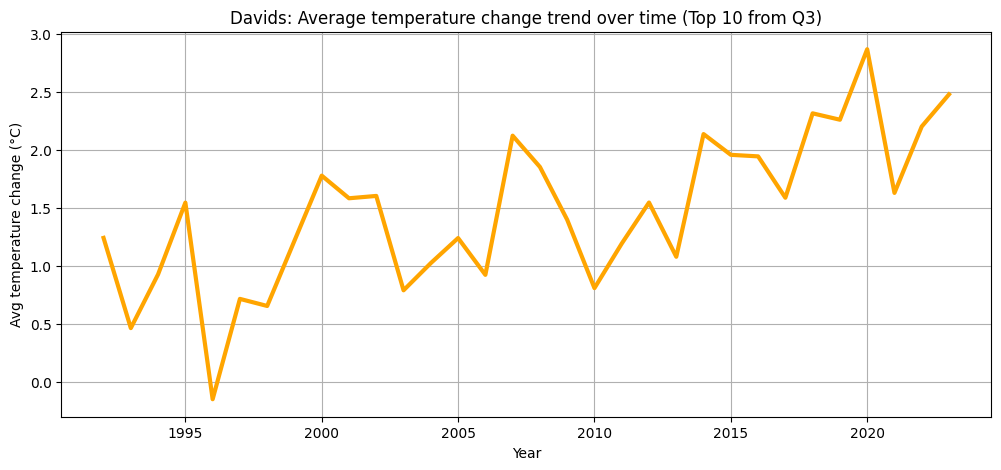

In [185]:
# Average trend across Davids for each year (without NaN values)
davids_yearly = df_davids[year_cols].mean(axis=0)

df_david_trend = pd.DataFrame({
    "year": [int(y) for y in year_cols],
    "davids_avg_temp_change": davids_yearly.values
}).sort_values("year")

plt.figure(figsize=(12, 5))
plt.plot(
    df_david_trend["year"], 
    df_david_trend["davids_avg_temp_change"], 
    linewidth=3,
    color="orange"
)
plt.title("Davids: Average temperature change trend over time (Top 10 from Q3)")
plt.xlabel("Year")
plt.ylabel("Avg temperature change (°C)")
plt.grid(True)
plt.show()

In [186]:
missing_g = set(goliaths_iso3) - set(df["iso_code"].dropna().unique())
missing_d = set(davids_iso3) - set(df_temp["ISO3"].dropna().unique())
print("Missing goliaths:", missing_g)
print("Missing davids:", missing_d)

Missing goliaths: set()
Missing davids: set()
